✅ Data Loaded Successfully!

First 5 rows:


,YEAR,MO,DY,HR,T2M,T2MDEW,T2MWET,RH2M,QV2M,PS,WS10M,WD10M,PRECTOTCORR
0,2014,11,1,0,24.92,21.53,23.23,81.41,16.01,100.76,4.97,37.2,0.0
1,2014,11,1,1,24.77,21.40,23.09,81.53,15.90,100.69,4.96,35.8,0.0
2,2014,11,1,2,24.67,21.30,22.98,81.56,15.82,100.63,4.94,34.8,0.0
3,2014,11,1,3,24.55,21.23,22.89,81.77,15.75,100.61,4.93,34.1,0.0
4,2014,11,1,4,24.44,21.16,22.80,82.07,15.70,100.62,4.97,33.2,0.0



Shape of dataset: (80376, 13)

✅ Columns renamed!

Missing values per column:
year             0
month            0
day              0
hour             0
temp             0
dew_point        0
wet_bulb         0
rel_humidity     0
spec_humidity    0
pressure         0
wind_speed       0
wind_dir         0
precipitation    0
dtype: int64

Number of duplicate rows: 0

✅ Datetime column created!

Max Precipitation Value: 355.96
Chosen Threshold (90th percentile): 9.4

Storm Value Counts:
storm
0    72345
1     8031
Name: count, dtype: int64

Storm Distribution (%):
storm
0    90.008211
1     9.991789
Name: proportion, dtype: float64


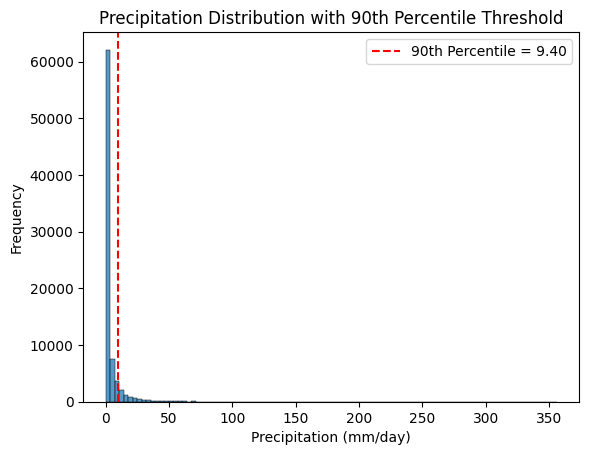

✅ Cleaned data saved as prepared.csv


In [ ]:
# ==============================
# 📦 IMPORTS
# ==============================
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)


# ==============================
# 📂 LOAD DATA
# ==============================
# Skip metadata rows (first 17 rows)
df = pd.read_csv("data.csv", skiprows=17)

print("✅ Data Loaded Successfully!\n")


# ==============================
# 👀 BASIC OVERVIEW
# ==============================
print("First 5 rows:")
display(df.head())

print("\nShape of dataset:", df.shape)


# ==============================
# 🏷️ RENAME COLUMNS
# ==============================
df.columns = [
    "year", "month", "day", "hour",
    "temp", "dew_point", "wet_bulb",
    "rel_humidity", "spec_humidity",
    "pressure", "wind_speed", "wind_dir",
    "precipitation"
]

print("\n✅ Columns renamed!")


# ==============================
# 🚨 HANDLE MISSING VALUES (-999)
# ==============================
df.replace(-999, np.nan, inplace=True)

print("\nMissing values per column:")
print(df.isnull().sum())


# ==============================
# 🔁 CHECK DUPLICATES
# ==============================
duplicates = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicates)

df = df.drop_duplicates()


# ==============================
# 🕒 CREATE DATETIME COLUMN
# ==============================
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])

df = df.sort_values("datetime").reset_index(drop=True)

print("\n✅ Datetime column created!")


# ==============================
# 📊 PRECIPITATION ANALYSIS
# ==============================

# Max precipitation (for understanding range)
max_precip = df["precipitation"].max()
print("\nMax Precipitation Value:", max_precip)

# 90th percentile threshold (DATA-DRIVEN)
threshold = df["precipitation"].quantile(0.90)
print("Chosen Threshold (90th percentile):", threshold)


# ==============================
# 🌧️ CREATE TARGET VARIABLE (STORM)
# ==============================
df["storm"] = (df["precipitation"] > threshold).astype(int)

print("\nStorm Value Counts:")
print(df["storm"].value_counts())

print("\nStorm Distribution (%):")
print(df["storm"].value_counts(normalize=True) * 100)


# ==============================
# 📊 VISUALIZATION (FULL RANGE)
# ==============================
plt.figure()

sns.histplot(df["precipitation"], bins=100)

# Threshold line
plt.axvline(threshold, color='red', linestyle='--',
            label=f'90th Percentile = {threshold:.2f}')

plt.legend()
plt.title("Precipitation Distribution with 90th Percentile Threshold")
plt.xlabel("Precipitation (mm/day)")
plt.ylabel("Frequency")

plt.show()

df.to_csv("prepared.csv", index=False)
print("✅ Cleaned data saved as prepared.csv")